# Modelisation du jeu de données nettoyé

Ce notebook présente une exploration PCA en 3D, un découpage train/test/validation, un appel à une fonction de prétraitement externe, et un entraînement en boucle de plusieurs modèles. *Ce workflow doit avoir le jeux de données nettoyé en entrée*

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import re

# add root path, to import all modules
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    
from src.accidents.data import load_collisions
from src.accidents.models.clustering import plot_3d, compute_methods

from sklearn.decomposition import PCA
from sklearn.manifold import MDS, Isomap
from sklearn.model_selection import train_test_split
import plotly.express as px

seed = 42

DATA_PATH = Path('../data/clean/collisions_clean.csv')
df = load_collisions(DATA_PATH)

Charge : 218,066 lignes x 52 colonnes  (collisions_clean.csv)


### Loader les colonnes et split

In [2]:
gravite_column = next((c for c in df.columns if c.upper() == 'GRAVITE_3'), None)
if gravite_column is None:
    raise ValueError('Impossible de trouver une colonne GRAVITE_3 dans le jeu de données nettoyé.')

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
feature_columns = [c for c in numeric_columns if not re.compile(r'^(?:GRAVITE|GRAVITE_3)$').match(c.upper())]
if not feature_columns:
    raise ValueError('Aucune colonne numérique disponible pour la PCA après exclusion de GRAVITE.')

X = df[feature_columns].copy()
y = df[gravite_column].copy()

print('Colonnes utilisées pour la PCA :', feature_columns[:10], '...')

Colonnes utilisées pour la PCA : ['NB_VEH_IMPLIQUES_ACCDN', 'NB_MORTS', 'NB_BLESSES_GRAVES', 'NB_BLESSES_LEGERS', 'AN', 'NB_VICTIMES_TOTAL', 'nb_automobile_camion_leger', 'nb_camionLourd_tractRoutier', 'nb_outil_equipement', 'nb_tous_autobus_minibus'] ...


## Exploration PCA 3D

Nous calculons une PCA sur les dimensions numériques en excluant `GRAVITE`, puis colorons le nuage 3D selon `GRAVITE`.

In [6]:
embeds = compute_methods(X, methods=["pca"])

for method, embed in embeds.items():
    fig = plot_3d(embed, labels=y, method_name=method, label_name=f"Gravité {method}")
    fig.show()

## Découpage train / validation / test

Nous préparons le jeu de données pour l'entraînement en séparant d'abord un test set, puis en divisant le reste entre entraînement et validation.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=seed
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=seed
)

print('Tailles :')
print('  X_train', X_train.shape)
print('  X_val', X_val.shape)
print('  X_test', X_test.shape)

Tailles :
  X_train (174452, 34)
  X_val (21807, 34)
  X_test (21807, 34)


### Check des petites classes

In [ ]:
print("Proportions de chaque classe des ensembles:")
print('  Y_train_proc', y_train.value_counts())
print('  Y_val_proc', y_val.value_counts())
print('  Y_test_proc', y_test.value_counts())

Proportions de chaque classe des ensembles:
  Y_train_proc GRAVITE_3
Materiel    136084
Leger        36730
Grave         1638
Name: count, dtype: int64
  Y_val_proc GRAVITE_3
Materiel    17011
Leger        4591
Grave         205
Name: count, dtype: int64
  Y_test_proc GRAVITE_3
Materiel    17011
Leger        4591
Grave         205
Name: count, dtype: int64


## Appel au prétraitement externe (**WIP**)

Ce notebook invoque une fonction de prétraitement située dans `src.accidents.preprocessing`. Si le module n'est pas encore implémenté, nous continuons avec les données brutes. (puisque **WIP**)

In [ ]:
try:
    from src.accidents.preprocessing.preprocessing import preprocess_data
except ImportError as exc:
    preprocess_data = None
    print('Prétraitement externe indisponible pour le moment :', exc)

if preprocess_data is None:
    X_train_proc, X_val_proc, X_test_proc = X_train, X_val, X_test
else:
    X_train_proc, X_val_proc, X_test_proc = preprocess_data(X_train, X_val, X_test)

print('Prétraitement terminé. Formes finales :')
print('  X_train_proc', X_train_proc.shape)
print('  X_val_proc', X_val_proc.shape)
print('  X_test_proc', X_test_proc.shape)

Prétraitement externe indisponible pour le moment : cannot import name 'preprocess_data' from 'src.accidents.preprocessing.preprocessing' (/home/xavierdrolet/projects/stt3795/classification_accidents/src/accidents/preprocessing/preprocessing.py)
Prétraitement terminé. Formes finales :
  X_train_proc (174452, 34)
  X_val_proc (21807, 34)
  X_test_proc (21807, 34)


## Boucle d'entraînement de modèles

Nous définissons plusieurs classifieurs scikit-learn, puis comparons leurs performances sur le jeu de validation.

GaussianNB: validation accuracy = 0.9951
Classification report:
              precision    recall  f1-score   support

       Grave       0.82      1.00      0.90       205
       Leger       0.99      0.99      0.99      4591
    Materiel       1.00      1.00      1.00     17011

    accuracy                           1.00     21807
   macro avg       0.94      1.00      0.96     21807
weighted avg       1.00      1.00      1.00     21807



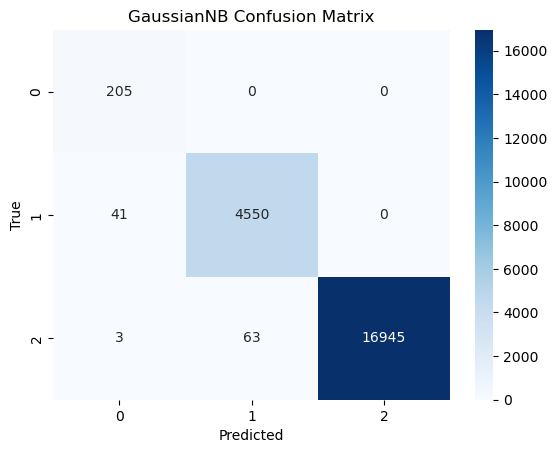

SVM: validation accuracy = 0.9994
Classification report:
              precision    recall  f1-score   support

       Grave       1.00      0.94      0.97       205
       Leger       1.00      1.00      1.00      4591
    Materiel       1.00      1.00      1.00     17011

    accuracy                           1.00     21807
   macro avg       1.00      0.98      0.99     21807
weighted avg       1.00      1.00      1.00     21807



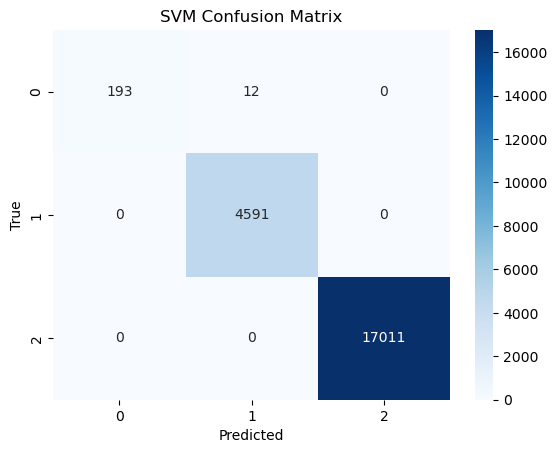

Random Forest: validation accuracy = 1.0000
Classification report:
              precision    recall  f1-score   support

       Grave       1.00      1.00      1.00       205
       Leger       1.00      1.00      1.00      4591
    Materiel       1.00      1.00      1.00     17011

    accuracy                           1.00     21807
   macro avg       1.00      1.00      1.00     21807
weighted avg       1.00      1.00      1.00     21807



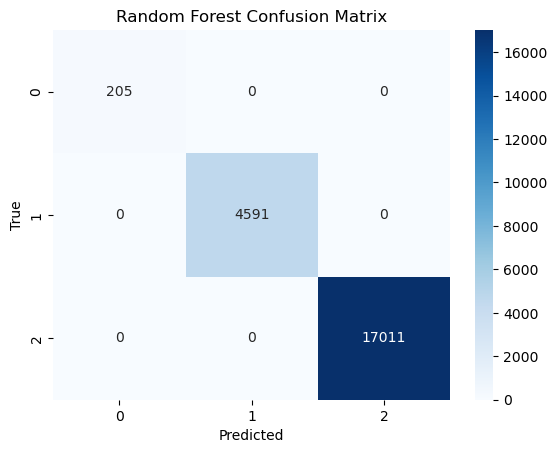

Résumé des performances :
  GaussianNB: 0.9951
  SVM: 0.9994
  Random Forest: 1.0000


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


models = {
    'GaussianNB': GaussianNB(),
    'SVM': LinearSVC(random_state=seed),
    'Random Forest': RandomForestClassifier(random_state=seed)
}

results = {}
for name, model in models.items():
    model.fit(X_train_proc, y_train)
    y_val_pred = model.predict(X_val_proc)
    score = accuracy_score(y_val, y_val_pred)
    results[name] = score
    print(f'{name}: validation accuracy = {score:.4f}')
    print("Classification report:")
    print(classification_report(y_val, y_val_pred))
    
    # plot confusion matrix
    sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

print('Résumé des performances :')
for name, score in results.items():
    print(f'  {name}: {score:.4f}')